In [47]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
df=pd.read_excel('Bank_Personal_Loan_Modelling.xlsx',sheet_name='Data')

In [49]:
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [51]:
df=df.drop('ID',axis=1)

In [52]:
# for col in df.columns:
#     q1 = df[col].quantile(0.25)
#     q3 = df[col].quantile(0.75)
#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     df = df[(df[col] >= lower) & (df[col] <= upper)]

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [54]:
df=df.drop('ZIP Code',axis=1)

In [55]:
df

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


In [56]:
from sklearn.model_selection import train_test_split

X=df.drop('Personal Loan',axis=1)
y=df['Personal Loan']
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [59]:
model=Sequential(
    [
        Dense(16,input_dim=X_train.shape[1], activation='relu'),
        Dense(8,activation='relu'),
        Dense(1,activation='sigmoid')
    ]
)

In [60]:
model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [61]:
model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.1)

Epoch 1/50
113/113 [==============================] - 1s 9ms/step - loss: 0.6661 - accuracy: 0.6631 - val_loss: 0.4645 - val_accuracy: 0.8100
Epoch 2/50
113/113 [==============================] - 1s 6ms/step - loss: 0.3638 - accuracy: 0.8764 - val_loss: 0.2818 - val_accuracy: 0.9250
Epoch 3/50
113/113 [==============================] - 1s 6ms/step - loss: 0.2289 - accuracy: 0.9375 - val_loss: 0.2078 - val_accuracy: 0.9375
Epoch 4/50
113/113 [==============================] - 1s 5ms/step - loss: 0.1766 - accuracy: 0.9464 - val_loss: 0.1759 - val_accuracy: 0.9350
Epoch 5/50
113/113 [==============================] - 1s 6ms/step - loss: 0.1555 - accuracy: 0.9456 - val_loss: 0.1632 - val_accuracy: 0.9375
Epoch 6/50
113/113 [==============================] - 1s 6ms/step - loss: 0.1446 - accuracy: 0.9489 - val_loss: 0.1597 - val_accuracy: 0.9325
Epoch 7/50
113/113 [==============================] - 1s 6ms/step - loss: 0.1402 - accuracy: 0.9464 - val_loss: 0.1496 - val_accuracy: 0.9475
Epoch 

In [62]:
model1=Sequential(
    [
        Dense(16,input_dim=X_train.shape[1], activation='sigmoid'),
        Dense(8,activation='sigmoid'),
        Dense(1,activation='sigmoid')
    ]
)
model1.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model1.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.1)

Epoch 1/50
113/113 [==============================] - 1s 6ms/step - loss: 0.9217 - accuracy: 0.1389 - val_loss: 0.6744 - val_accuracy: 0.7925
Epoch 2/50
113/113 [==============================] - 1s 5ms/step - loss: 0.5624 - accuracy: 0.9044 - val_loss: 0.4904 - val_accuracy: 0.8925
Epoch 3/50
113/113 [==============================] - 1s 5ms/step - loss: 0.4385 - accuracy: 0.9078 - val_loss: 0.4151 - val_accuracy: 0.8925
Epoch 4/50
113/113 [==============================] - 1s 4ms/step - loss: 0.3805 - accuracy: 0.9078 - val_loss: 0.3740 - val_accuracy: 0.8925
Epoch 5/50
113/113 [==============================] - 1s 5ms/step - loss: 0.3457 - accuracy: 0.9078 - val_loss: 0.3464 - val_accuracy: 0.8925
Epoch 6/50
113/113 [==============================] - 1s 5ms/step - loss: 0.3214 - accuracy: 0.9078 - val_loss: 0.3256 - val_accuracy: 0.8925
Epoch 7/50
113/113 [==============================] - 1s 5ms/step - loss: 0.3028 - accuracy: 0.9078 - val_loss: 0.3084 - val_accuracy: 0.8925
Epoch 

In [63]:
model2=Sequential(
    [
        Dense(16,input_dim=X_train.shape[1], activation='tanh'),
        Dense(8,activation='tanh'),
        Dense(1,activation='sigmoid')
    ]
)
model2.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model2.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.1)

Epoch 1/50
113/113 [==============================] - 1s 6ms/step - loss: 0.5274 - accuracy: 0.7700 - val_loss: 0.3811 - val_accuracy: 0.8900
Epoch 2/50
113/113 [==============================] - 1s 5ms/step - loss: 0.2895 - accuracy: 0.9114 - val_loss: 0.2288 - val_accuracy: 0.9225
Epoch 3/50
113/113 [==============================] - 0s 4ms/step - loss: 0.1871 - accuracy: 0.9400 - val_loss: 0.1722 - val_accuracy: 0.9400
Epoch 4/50
113/113 [==============================] - 0s 4ms/step - loss: 0.1483 - accuracy: 0.9567 - val_loss: 0.1448 - val_accuracy: 0.9500
Epoch 5/50
113/113 [==============================] - 1s 5ms/step - loss: 0.1305 - accuracy: 0.9583 - val_loss: 0.1326 - val_accuracy: 0.9500
Epoch 6/50
113/113 [==============================] - 0s 4ms/step - loss: 0.1196 - accuracy: 0.9589 - val_loss: 0.1232 - val_accuracy: 0.9600
Epoch 7/50
113/113 [==============================] - 0s 4ms/step - loss: 0.1118 - accuracy: 0.9631 - val_loss: 0.1150 - val_accuracy: 0.9625
Epoch 

In [64]:
history1 = model1.fit(X_train, y_train,
                      validation_data=(X_test, y_test),
                      epochs=50,
                      batch_size=32,
                      verbose=0)

history2 = model2.fit(X_train, y_train,
                      validation_data=(X_test, y_test),
                      epochs=50,
                      batch_size=32,
                      verbose=0)

history3 = model.fit(X_train, y_train,
                      validation_data=(X_test, y_test),
                      epochs=50,
                      batch_size=32,
                      verbose=0)

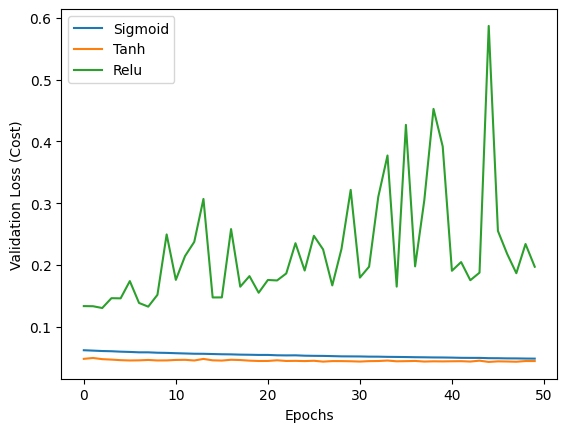

In [65]:
plt.plot(history1.history['val_loss'], label='Sigmoid')
plt.plot(history2.history['val_loss'], label='Tanh')
plt.plot(history3.history['val_loss'], label='Relu')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss (Cost)')
plt.legend()
plt.show()

In [66]:
loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
loss3, acc3 = model.evaluate(X_test, y_test, verbose=0)

print(acc1,acc2,acc3)

0.984000027179718 0.9879999756813049 0.9409999847412109


In [67]:
from sklearn.metrics import f1_score

y_pred1 = (model1.predict(X_test) > 0.5).astype(int)
y_pred2 = (model2.predict(X_test) > 0.5).astype(int)
y_pred3 = (model.predict(X_test) > 0.5).astype(int)

32/32 [==============================] - 0s 1ms/step


In [70]:
print("Sigmoid F1-score:", f1_score(y_test, y_pred1))
print("tanh F1-score:", f1_score(y_test, y_pred2))
print("relu F1-score:", f1_score(y_test, y_pred3))

Sigmoid F1-score: 0.9215686274509803
tanh F1-score: 0.941747572815534
relu F1-score: 0.7354260089686099
